In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

class GaussianMixture:
    def __init__(self, mean1, mean2, cov1, cov2, w1=0.5, w2=0.5):
        self.means = [mean1, mean2]
        self.covs = [cov1, cov2]
        self.z = [ multivariate_normal(mean1, cov1), multivariate_normal(mean2, cov2)]
        assert np.isclose(w1+w2, 1), "weights must sum to one"
        self.w = [w1, w2]
    
    def __call__(self, positions):
        return self.w[0] * self.z[0].pdf(positions) + self.w[1] * self.z[1].pdf(positions)
    
    def sample(self, n_samples):
        samples = np.zeros((n_samples, 2))
        for i in range(n_samples):
            rnd = np.random.random(1)[0]
            if rnd > self.w[0]:
                index = 1
            else:
                index = 0
            samp = np.random.multivariate_normal(mean=self.means[index], cov=self.covs[index], size=1)
            samples[i,:] = samp
        return samples

Visualize a mixture of 2 gaussians pdf and its score function

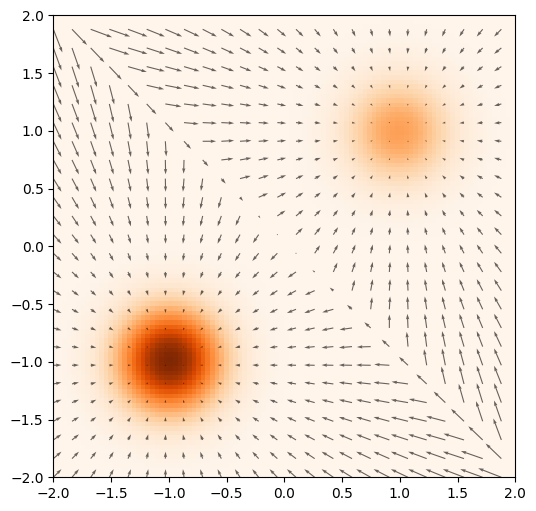

In [3]:
# Grid settings
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)

pos = np.dstack((X, Y))

sigma_1, sigma_2 = 0.1, 0.1
mean1, cov1 = [1, 1], [[sigma_1, 0], [0, sigma_1]]
mean2, cov2 = [-1, -1], [[sigma_2, 0], [0, sigma_2]]
gauss_mix = GaussianMixture(mean1, mean2, cov1, cov2, w1=0.3, w2=0.7)

pdf_pos = gauss_mix(pos)
logs = np.log( pdf_pos )

# Compute score
dx, dy = np.gradient(logs)  # Partial derivatives

# Create the plot
fig, ax = plt.subplots(figsize=(6,6))

# Plot the vector field

skip = (slice(None, None, 4), slice(None, None, 4))
ax.quiver(X[skip], Y[skip], dy[skip], dx[skip], color='black', alpha=0.6)


# Overlay the Gaussian heatmap
ax.imshow(pdf_pos, extent=[-2, 2, -2, 2], origin="lower", cmap="Oranges")

# Show plot
plt.show()

In [4]:
class NoiseConditionalScoreNetwork(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim+1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, in_dim)
        )
    
    def forward(self, x, sigma):
        return self.net(torch.cat([x,sigma], dim=-1))
    
def geometric_progression(first, last, n):
    r = (last / first) ** (1 / (n - 1))
    return [first * r**i for i in range(n)]

In [5]:
# Training parameters
lr = 1e-3
epochs = 10_000  # Increased epochs
batch_size = 128
sigmas = np.array( geometric_progression(2, 0.05, 100) )

Generate data

In [6]:
n_train_samples = 4_000
data = gauss_mix.sample(n_train_samples)
data = torch.tensor(data, dtype=torch.float32)

In [7]:
dataloader = torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=True)
model = NoiseConditionalScoreNetwork(in_dim=2, hidden_dim=128)
optimizer = optim.Adam(model.parameters(), lr=lr)

In [8]:
for epoch in range(epochs):
    total_loss = 0
    for batch in dataloader:
        sampled_sigmas = torch.tensor(sigmas[ np.random.randint(0, len(sigmas)-1, batch.shape[0]) ], dtype=torch.float32 ).unsqueeze(1)
        z = sampled_sigmas * torch.randn_like(batch)

        noisy_batch = batch + z
        score = z / sampled_sigmas**2
        predicted_score = model(noisy_batch, sampled_sigmas)
        
        loss = ((sampled_sigmas**2) * (predicted_score + score) ** 2).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if epoch % 1_000 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss / len(dataloader):.4f}")
        
print(f"Epoch {epoch}, Loss: {total_loss / len(dataloader):.4f}")

Epoch 0, Loss: 0.8107
Epoch 1000, Loss: 0.5716
Epoch 2000, Loss: 0.5360
Epoch 3000, Loss: 0.5673
Epoch 4000, Loss: 0.5426
Epoch 5000, Loss: 0.5482
Epoch 6000, Loss: 0.5580
Epoch 7000, Loss: 0.5484
Epoch 8000, Loss: 0.5875
Epoch 9000, Loss: 0.5572
Epoch 9999, Loss: 0.5581


In [9]:
# Sampling using Langevin dynamics
def sample_langevin(model, prior, sigma, step_size, steps=5000,):
    # prior initialization
    x = prior #torch.randn(n_samples, 2) * 2  
    sigma = torch.tensor(sigma, dtype=torch.float32).repeat(prior.shape[0]).unsqueeze(1)
    for _ in range(steps):
        z =  torch.randn_like(x) * np.sqrt(step_size)
        score = model(x, sigma).detach()
        x = x + step_size/2 * score + z
    return x.numpy()

In [10]:
n_samples = 1000
prior = torch.randn( n_samples, 2 ) 
epsilon=0.001
for i, sigma in enumerate(sigmas):    
    step_size = epsilon * sigma**2/sigmas[-1]**2
    x = sample_langevin(model, prior, sigma, step_size, steps=1_000)
    prior = torch.tensor(x)

<Figure size 640x480 with 0 Axes>

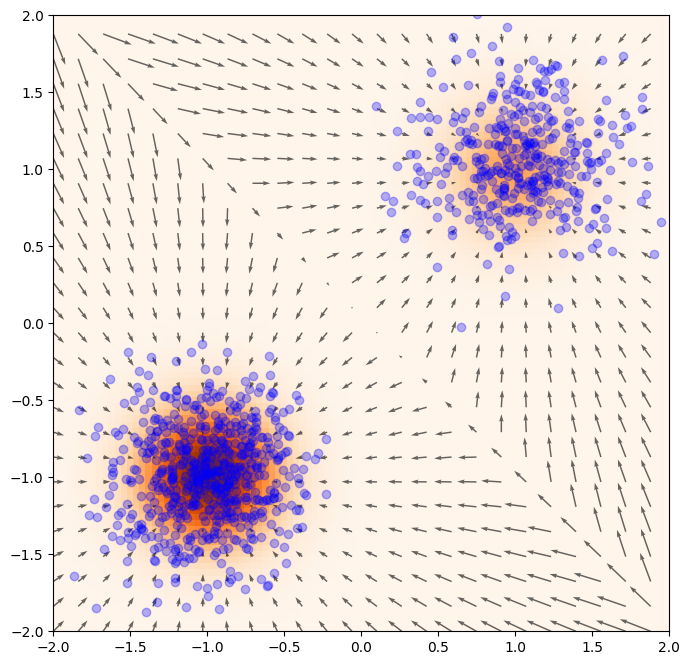

In [11]:
# Generate and plot samples
plt.clf()
fig, ax = plt.subplots(figsize=(8,8))

ax.imshow(pdf_pos, extent=[-2, 2, -2, 2], origin="lower", cmap="Oranges")
ax.quiver(X[skip], Y[skip], dy[skip], dx[skip], color='black', alpha=0.6)

#ax.scatter(data[:, 0], data[:, 1], alpha=0.3, label="Real Data", color="blue")
ax.scatter(x[:, 0], x[:, 1], alpha=0.3, label="Generated Data", color="b")
ax.set_xlim([-2,2])
ax.set_ylim([-2,2])

plt.show()

<Figure size 640x480 with 0 Axes>

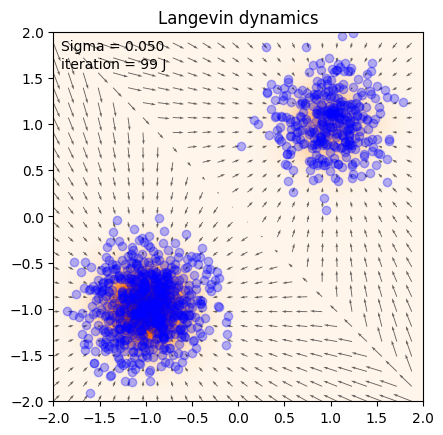

<Figure size 800x600 with 0 Axes>

In [12]:
import matplotlib.animation as animation

plt.clf()
fig, ax = plt.subplots()
plt.figure(figsize=(8, 6))

ax.imshow(pdf_pos, extent=[-2, 2, -2, 2], origin="lower", cmap="Oranges")
ax.quiver(X[skip], Y[skip], dy[skip], dx[skip], color='black', alpha=0.6)

ims = []
prior = torch.randn(n_samples, 2) 
for i, sigma in enumerate(sigmas):    
    step_size = epsilon * sigma**2/sigmas[-1]**2
    x = sample_langevin(model, prior, sigma, step_size, steps=1_000)
    prior = torch.tensor(x)

    # Generate and plot samples
    #p1 = ax.scatter(data[:, 0], data[:, 1], alpha=0.3, label="Real Data", color="blue")
    p2 = ax.scatter(x[:, 0], x[:, 1], alpha=0.3, label="Generated Data", color="b")
    p3 = ax.text(0.02, 0.95, 'Sigma = %1.3f' % sigma, transform=ax.transAxes)
    p4 = ax.text(0.02, 0.90, 'iteration = %2.0f J' % i, transform=ax.transAxes)

    ims.append([p2,p3,p4])


ax.set_xlim([-2,2])
ax.set_ylim([-2,2])

ax.set_title('Langevin dynamics')

ani = animation.ArtistAnimation(fig, ims, interval=50, blit=True)
ani.save('gauss_mix.mp4')